In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, HTML
from astroquery.gaia import Gaia
from scipy.optimize import minimize
from scipy.interpolate import RegularGridInterpolator
from isochrones.mist import MIST_Isochrone
import emcee
import corner

mist = MIST_Isochrone()

In [2]:
# helper function that converts ra and dec to distance (pc)
def get_distance_pc(ra, dec, radius=2/3600):
    """
    Query Gaia DR3 for parallax near RA/Dec
    Returns distance in parsecs
    """

    query = f"""
    SELECT TOP 1 parallax
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
    ) = 1
    """

    job = Gaia.launch_job(query)
    result = job.get_results()

    if len(result) == 0:
        return np.nan

    parallax = result['parallax'][0]

    if parallax <= 0:
        return np.nan

    return 1000.0 / parallax

# helper functio that converts apparent magnitude to absoulte magniutde
def apparent_to_absolute(m, d_pc):
    return m - 5*np.log10(d_pc) + 5

In [3]:
# load and clean the stellar sample
df1 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Target_List.csv")
df2 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Photometry_List.csv")

df1 = df1.drop_duplicates(subset="hostname")
df2 = df2.drop_duplicates(subset="hostname")

merged = pd.merge(df1, df2, on="hostname", how="inner")

merged["ra"] = merged["ra_x"]
merged["dec"] = merged["dec_x"]

merged = merged.drop(columns=["ra_x","ra_y","dec_x","dec_y","pl_name_y"])

merged = merged[[
    "hostname",
    "st_teff","st_age","st_met",
    "ra","dec",
    "gaia_Gmag","gaia_BPmag","gaia_RPmag",
    "Jmag","Hmag","Kmag",
    "e_Jmag","e_Hmag","e_Kmag"
]]

merged = merged.dropna(subset=[
    "st_teff","st_age","st_met",
    "ra","dec",
    "gaia_Gmag","gaia_BPmag","gaia_RPmag",
    "Jmag","Hmag","Kmag"
])

# young stars only
merged = merged[merged["st_age"] < 1.0]

merged["st_met"] = merged["st_met"].fillna(0.0)
merged["e_Jmag"] = merged["e_Jmag"].fillna(0.03)
merged["e_Hmag"] = merged["e_Hmag"].fillna(0.03)
merged["e_Kmag"] = merged["e_Kmag"].fillna(0.03)

display(HTML(merged.head(20).to_html()))

,hostname,st_teff,st_age,st_met,ra,dec,gaia_Gmag,gaia_BPmag,gaia_RPmag,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag
11,TOI-6016,6110.0,0.300,0.2800,4.523960,59.766198,11.909994,12.331106,11.320911,10.629,10.308,10.224,0.021,0.015,0.016
14,Qatar-4,5215.0,0.170,0.1030,4.859275,44.027597,13.400405,13.867678,12.771313,12.030,11.631,11.519,0.020,0.021,0.020
22,Qatar-5,5747.0,0.530,0.3770,7.053937,42.061345,12.511989,12.887348,11.975026,11.348,11.089,10.956,0.023,0.021,0.020
29,WASP-93,6700.0,0.700,0.0700,9.458744,51.288778,10.984386,11.209536,10.591513,10.233,9.997,9.942,0.022,0.021,0.016
66,TOI-2046,6250.0,0.450,-0.0600,16.184942,74.331305,11.408128,11.718330,10.933183,10.415,10.125,10.094,0.024,0.031,0.023
110,TOI-2152,6630.0,0.830,0.2820,26.338972,77.790123,11.243453,11.661012,10.635723,9.973,9.669,9.597,0.026,0.030,0.024
120,TOI-262,5310.0,0.800,0.2600,32.534687,-31.070627,8.677938,9.109069,8.081018,7.387,7.051,6.967,0.023,0.040,0.020
136,GPX-1,7000.0,0.270,0.3500,38.369165,56.025708,12.212760,12.461465,11.815224,11.357,11.221,11.181,0.026,0.024,0.021
155,HD 18599,5145.0,0.400,0.0000,44.262014,-56.191869,8.741666,9.190199,8.127134,7.428,7.029,6.883,0.018,0.015,0.020
171,WASP-139,5310.0,0.500,0.2000,49.562173,-41.302023,12.264109,12.701511,11.666922,10.982,10.575,10.472,0.023,0.023,0.021


In [4]:
# query gaia distances
merged["distance_pc"] = merged.apply(
    lambda row: get_distance_pc(row["ra"], row["dec"]),
    axis=1
)

merged = merged.dropna(subset=["distance_pc"])

print("Stars with distances:", len(merged))

Stars with distances: 237


In [5]:
# build mist interpolation grid
age_grid  = np.linspace(6.0,10.2,60)
feh_grid  = np.linspace(-2.5,0.5,31)
mass_grid = np.linspace(0.1,10.0,200)

bands_interp = [
    'J_mag','H_mag','K_mag',
    'G_mag','BP_mag','RP_mag',
    'Teff'
]

shape = (len(age_grid),len(feh_grid),len(mass_grid))

cubes = {band: np.full(shape,np.nan) for band in bands_interp}

for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):

        iso = mist.isochrone(age, feh)

        if iso.empty:
            continue

        iso = iso.sort_values("initial_mass")

        for band in bands_interp:

            cubes[band][i,j,:] = np.interp(
                mass_grid,
                iso["initial_mass"],
                iso[band],
                left=np.nan,
                right=np.nan
            )

In [6]:
# create interpolators
interpolators = {}

for band in bands_interp:

    interpolators[band] = RegularGridInterpolator(
        (age_grid,feh_grid,mass_grid),
        cubes[band],
        bounds_error=False,
        fill_value=np.nan
    )

In [26]:
# chi-squared model
fit_bands = ["G","BP","RP","J","H","K"]
band_map = {b: b+"_mag" for b in fit_bands}

def chi2_model(params, star):

    logage, mass = params
    feh = np.clip(star["feh"], feh_grid.min(), feh_grid.max())

    y = np.array([star["photometry"][b] for b in fit_bands])
    yerr = np.array([star["phot_err"].get(b,0.02) for b in fit_bands])

    model_mags = np.array([
        interpolators[band_map[b]]([[logage,feh,mass]])[0]
        for b in fit_bands
    ])

    if np.any(np.isnan(model_mags)):
        return 1e10

    chi2_phot = np.sum(((y-model_mags)/yerr)**2)

    Teff_obs = star["Teff"]
    Teff_err = star.get("Teff_err",100)

    Teff_model = interpolators["Teff"]([[logage,feh,mass]])[0]

    if np.isnan(Teff_model):
        return 1e10

    chi2_teff = ((Teff_obs-Teff_model)/Teff_err)**2

    return chi2_phot + chi2_teff

# log-probability function
def log_probability(params, star):

    logage, mass = params

    # parameter bounds (same as optimizer)
    if not (6.0 < logage < 9.0):
        return -np.inf

    if not (0.1 < mass < 10.0):
        return -np.inf

    chi2 = chi2_model(params, star)

    return -0.5 * chi2

# MCMC fitting function
def fit_star_emcee(star):

    ndim = 2
    nwalkers = 32
    steps = 2000

    initial = np.array([7.5, 1.0])
    logage_init = np.random.uniform(6.0, 9.0, nwalkers)
    mass_init = np.random.uniform(0.5, 2.0, nwalkers)
    pos = np.vstack([logage_init, mass_init]).T

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(star,)
    )

    sampler.run_mcmc(pos, steps, progress=True)
    samples = sampler.get_chain(discard=500, flat=True)

    logage_samples = samples[:,0]
    mass_samples = samples[:,1]
    age_samples = 10**logage_samples / 1e9
    age_median = np.median(age_samples)
    age_err = np.std(age_samples)
    mass_median = np.median(mass_samples)
    mass_err = np.std(mass_samples)

    return {
    "hostname": star["hostname"],
    "age_catalog": star["age_true"],
    "age_median": age_median,
    "age_err": age_err,
    "mass_median": mass_median,
    "mass_err": mass_err
}, samples

In [27]:
# fit a star
def fit_star(star):

    initial_guess = [7.5,1.0]

    bounds = [
    (6.0, 9.0),   # 1 Myr → 1 Gyr
    (0.1, 10.0)
    ]

    result = minimize(
        chi2_model,
        initial_guess,
        args=(star,),
        bounds=bounds,
        method="L-BFGS-B"
    )

    best_logage,best_mass = result.x

    return {
        "hostname": star["hostname"],
        "age_catalog": star["age_true"],
        "age_fit": 10**best_logage / 1e9,
        "mass_fit": best_mass,
        "feh": star["feh"],
        "ra": star["ra"],
        "dec": star["dec"],
        "distance_pc": star["distance_pc"]
    }

In [9]:
# convert dataframes to star dicts
def row_to_star(row):

    d = row["distance_pc"]

    star = {
        "hostname": row["hostname"],
        "ra": row["ra"],
        "dec": row["dec"],
        "distance_pc": d,
        "photometry": {
            "G": apparent_to_absolute(row["gaia_Gmag"], d),
            "BP": apparent_to_absolute(row["gaia_BPmag"], d),
            "RP": apparent_to_absolute(row["gaia_RPmag"], d),
            "J": apparent_to_absolute(row["Jmag"], d),
            "H": apparent_to_absolute(row["Hmag"], d),
            "K": apparent_to_absolute(row["Kmag"], d),
        },
        "phot_err": {
            "G":0.01,
            "BP":0.01,
            "RP":0.01,
            "J":row["e_Jmag"],
            "H":row["e_Hmag"],
            "K":row["e_Kmag"]
        },
        "Teff": row["st_teff"],
        "feh": row["st_met"],
        "age_true": row["st_age"]
    }

    return star

In [10]:
# run fits
star_dicts = [row_to_star(row) for _,row in merged.iterrows()]

results = []

for star in star_dicts:

    try:
        fit = fit_star(star)
        results.append(fit)

    except Exception as e:
        print("Failed:", star["hostname"], e)

results_df = pd.DataFrame(results)

results_df

,hostname,age_catalog,age_fit,mass_fit,feh,ra,dec,distance_pc
0,TOI-6016,0.300,0.011264,1.410739,0.280,4.523960,59.766198,363.747188
1,Qatar-4,0.170,0.048755,0.841246,0.103,4.859275,44.027597,327.154515
2,Qatar-5,0.530,0.030865,1.088775,0.377,7.053937,42.061345,372.259051
3,WASP-93,0.700,0.014834,1.392987,0.070,9.458744,51.288778,372.001405
4,TOI-2046,0.450,0.019493,1.114512,-0.060,16.184942,74.331305,287.947853
...,...,...,...,...,...,...,...,...
232,WASP-52,0.400,0.041209,0.839120,0.030,348.494793,8.761079,174.636787
233,WASP-59,0.500,0.037245,0.691970,-0.150,349.622955,24.889277,116.039378
234,TOI-251,0.180,0.029818,0.976313,-0.106,353.062066,-37.255863,101.004225
235,DS Tuc A,0.045,0.031888,0.927603,0.000,354.915467,-69.196043,44.175959


In [11]:
# evaulate fit accuracy
results_df["age_diff_pct"] = (
    abs(results_df["age_catalog"] - results_df["age_fit"])
    / results_df["age_catalog"]
) * 100

print(results_df["age_diff_pct"].describe())

count    237.000000
mean            inf
std             NaN
min        0.691177
25%       89.581769
50%       93.748447
75%       96.429969
max             inf
Name: age_diff_pct, dtype: float64


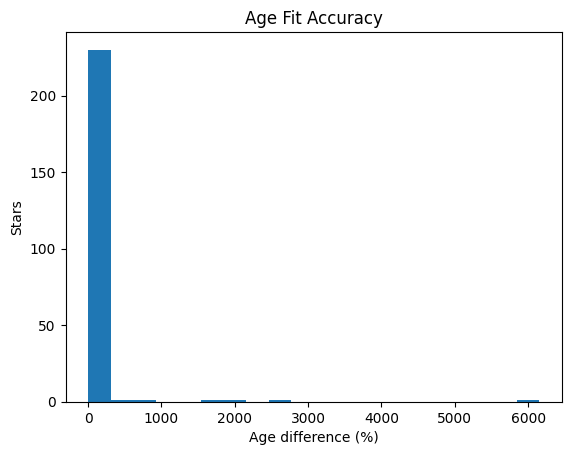

In [12]:
# plot age error distribution
results_df["age_diff_pct"] = (
    abs(results_df["age_catalog"] - results_df["age_fit"])
    / results_df["age_catalog"]
) * 100

results_df = results_df.replace([np.inf, -np.inf], np.nan)

results_df = results_df.dropna(subset=["age_diff_pct"])

plt.hist(results_df["age_diff_pct"], bins=20)
plt.xlabel("Age difference (%)")
plt.ylabel("Stars")
plt.title("Age Fit Accuracy")
plt.show()

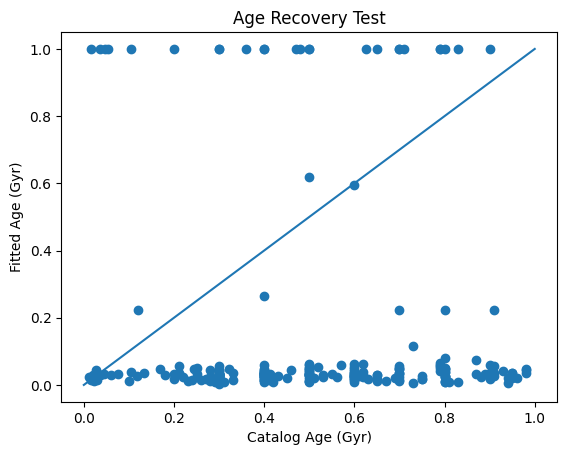

In [13]:
plt.scatter(results_df["age_catalog"], results_df["age_fit"])
plt.plot([0,1],[0,1])
plt.xlabel("Catalog Age (Gyr)")
plt.ylabel("Fitted Age (Gyr)")
plt.title("Age Recovery Test")
plt.show()

In [16]:
star = star_dicts[0]

fit, samples = fit_star_emcee(star)

print(fit)

100%|██████████| 2000/2000 [00:36<00:00, 54.25it/s]

{'hostname': 'TOI-6016', 'age_median': 0.011233872324688464, 'age_err': 0.0012802677562517763, 'mass_median': 1.411430518009889, 'mass_err': 0.021315776966477382}


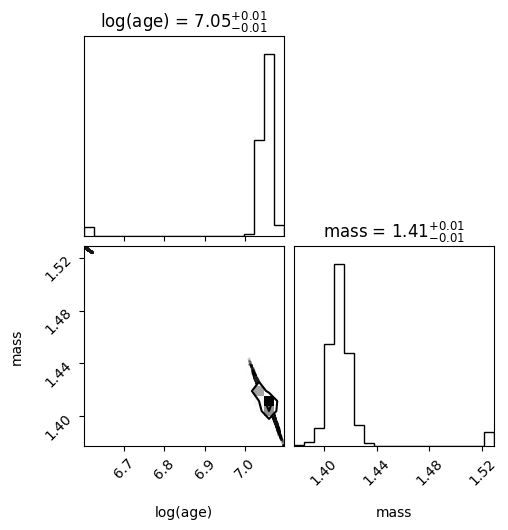

In [17]:
figure = corner.corner(
    samples,
    labels=["log(age)", "mass"],
    show_titles=True
)

In [28]:
results = []
sample_list = []

for star in star_dicts[:10]:

    fit, samples = fit_star_emcee(star)

    results.append(fit)
    sample_list.append(samples)

results_df = pd.DataFrame(results)

100%|██████████| 2000/2000 [00:33<00:00, 59.06it/s]


In [29]:
results_df

,hostname,age_catalog,age_median,age_err,mass_median,mass_err
0,TOI-6016,0.30,0.011347,0.382434,1.408854,0.070491
1,Qatar-4,0.17,0.580784,0.291691,0.872517,0.008776
2,Qatar-5,0.53,0.030955,0.324308,1.091779,0.015660
3,WASP-93,0.70,0.014876,0.423166,1.395546,0.003730
4,TOI-2046,0.45,0.019577,0.368746,1.115065,0.008645
5,TOI-2152,0.83,0.007930,0.170850,1.603916,0.052308
6,TOI-262,0.80,0.178509,0.276691,0.962074,0.011608
7,GPX-1,0.27,0.947430,0.476896,1.488169,0.056865
8,HD 18599,0.40,0.469985,0.322631,0.854318,0.011652
9,WASP-139,0.50,0.209132,0.258024,0.924945,0.007374


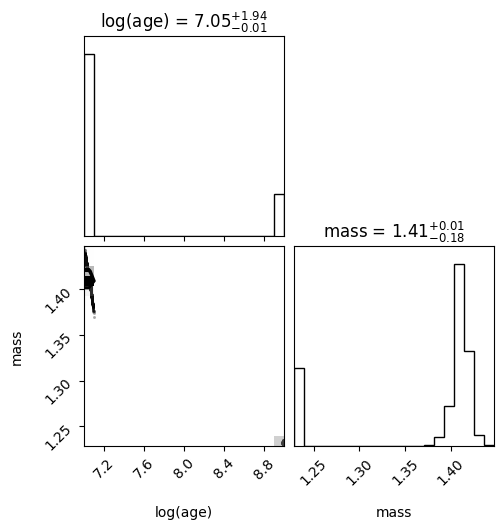

In [30]:
samples = sample_list[0]

figure = corner.corner(
    samples,
    labels=["log(age)", "mass"],
    show_titles=True
)